# Solution - Audit and rescue the rent model

Instructor solution. The starter `buggy_rent_model.ipynb` hides **twelve** methodology
bugs (L04-L07). Below: the filled audit table (Part 1), the corrected pipeline
(Part 2), the honest model + model card (Part 3), and an optional appendix.

**Key teaching point:** most of these bugs **barely move the headline number** -
a model can be riddled with errors and still print R² ≈ 0.85. You catch them by
reading the code against the rules, not by hunting for a value that looks wrong.

## Part 1 - Audit

| # | Bug (where in the starter) | Rule | Why it's wrong (and its real impact here) |
|---|---|---|---|
| **1** | `locality_mean_rent` and `ohe.fit_transform` both on the **full df, before the split** | **L04** leakage | locality mean is built from test rows' rents (and the row's own) → the model peeks at the target. **Inflates sealed-test log-R² by ~0.03.** |
| **2** | alpha chosen by `r2_score(y_test, ...)` in the sweep | **L04** | model selection peeks at the test set. (Here the peeked alpha = the CV choice, so ~0 gain - but invalid in principle.) |
| **3** | `Ridge` on **unscaled** features | **L05** | penalty fair only by luck; no score impact once tuned, but breaks interpretation and bites when regularization grips. |
| **4** | alpha grid `[0.1..1.0]` - linear, narrow | **L06** | winner sits at the **boundary** (1.0); can't tell the optimum isn't outside. Use log-uniform + widen. |
| **5** | importance read off **unscaled** `\|coef\|` | **L05/L07** | `Size`, `locality_mean_rent` get tiny coefs (values in the thousands) → rank **last**, the opposite of truth. Magnitude ≠ importance unless scaled. |
| **6** | RMSE/MAE on the **log** target; R² compared across y-subsets | **L07** | log-RMSE ≈ 0.36 looks tiny, but the rupee error is tens of thousands. And R² shifts with the range, so comparing it across subsets is meaningless. |
| **7** | R², RMSE, MAE all computed on **`X_train`** (in-sample) and reported as quality | **L04** | training error always looks good - it's what we fit. Says nothing about generalization (the chapter's opening lesson). |
| **8** | `cross_val_score(scoring="neg_mean_squared_error")` printed as "MSE" | **L07** | sklearn returns the **negative** MSE → "MSE = -0.15" is nonsense. Negate it / use a positive scorer. |
| **9** | the "FINAL" number is a CV score on the **leaked train** matrix; no sealed test | **L04/L06** | no untouched evaluation anywhere; the test set is only ever used for peeking (bug 2). Report a sealed test once. |
| **10** | **no `random_state`** on split / KFold | **L04** | every run reshuffles → different "best alpha" and score each time. Not reproducible. Seed everything. |
| **11** | Pearson `correlation(pred, actual)` reported as accuracy | **L07** | correlation measures *association*, not accuracy: a constant offset scores r = 1.0 with huge error (demo in Part 3). |
| **12** | `OneHotEncoder` **without `drop="first"`** | **L05** | the dummy-variable trap - the $k$ category columns sum to 1, collinear with the intercept (singular for OLS; Ridge fits but coefficients get mangled, worsening bug 5). HW2 used `drop="first"` for exactly this. |

**Bonus catch:** no `DummyRegressor` baseline, so "R² ≈ 0.85" has no reference point.

## Part 2 - The fix

Seed everything; split first; all preprocessing in a `Pipeline` (refit per fold,
scaled, `drop="first"`); alpha tuned by CV on **train only** over a wide log range;
test set sealed.

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import (train_test_split, GridSearchCV, KFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, median_absolute_error)

SEED = 509                       # fixes bug 10
np.random.seed(SEED)
ARM_RED, ARM_BLUE = "#D90012", "#0033A0"

df = pd.read_csv("../01_regression_intro/data/House_Rent_Dataset.csv")
num = ["BHK", "Size", "Bathroom"]            # leaky locality feature dropped
cat = ["City", "Furnishing Status", "Area Type"]
X = df[num + cat]
y_raw = df["Rent"].values
y_log = np.log1p(y_raw)

X_tr, X_te, ylog_tr, ylog_te, yraw_tr, yraw_te = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=SEED)
print("train:", X_tr.shape, " test:", X_te.shape, " (test sealed until Part 3)")

train: (3796, 6)  test: (950, 6)  (test sealed until Part 3)


In [2]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num),                                    # fixes 3
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat),  # fixes 12 (dummy trap)
])
pipe = Pipeline([("pre", pre), ("ridge", Ridge())])
grid = {"ridge__alpha": np.logspace(-3, 3, 13)}                        # fixes 4
gs = GridSearchCV(pipe, grid, cv=KFold(5, shuffle=True, random_state=SEED),
                  scoring="r2")                                        # fixes 2
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Found unknown categories")
    gs.fit(X_tr, ylog_tr)
best = gs.best_params_["ridge__alpha"]
print(f"best alpha = {best:g}   CV R2(log) = {gs.best_score_:.3f}   interior: {1e-3 < best < 1e3}")

best alpha = 1   CV R2(log) = 0.790   interior: True


In [3]:
# fixes bug 8: cross_val_score returns the NEGATIVE MSE (sklearn maximizes by convention) -
# negate it to report a real, positive error instead of the starter's "MSE = -0.15".
cv_mse = -cross_val_score(gs.best_estimator_, X_tr, ylog_tr,
                          cv=KFold(5, shuffle=True, random_state=SEED),
                          scoring="neg_mean_squared_error").mean()
print(f"CV MSE (log) = {cv_mse:.3f}  (negated to a positive number)")

CV MSE (log) = 0.185  (negated to a positive number)


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Feature importance, done right (fixes bug 5)

Unscaled vs scaled `|coef|`: with a common scale the ranking **inverts** - `Size`
and `locality_mean_rent` go from last to top. (We reuse the starter's leaky
`locality_mean_rent` here *only* to make the scaling effect vivid - it is bug 1 and
is **not** in the real model; this fit is train-only.)

In [4]:
feats = num + ["locality_mean_rent"]
Xi = X_tr[num].copy()
Xi["locality_mean_rent"] = df.loc[X_tr.index].groupby("Area Locality")["Rent"].transform("mean")
unscaled = Ridge(alpha=1.0).fit(Xi.values, ylog_tr).coef_
scaled = Ridge(alpha=1.0).fit(StandardScaler().fit_transform(Xi.values), ylog_tr).coef_
cmp = pd.DataFrame({"|coef| unscaled": np.abs(unscaled), "|coef| scaled": np.abs(scaled)}, index=feats)
print(cmp.round(4))
print("\nUnscaled rank:", list(cmp["|coef| unscaled"].sort_values(ascending=False).index))
print("Scaled rank  :", list(cmp["|coef| scaled"].sort_values(ascending=False).index))

                    |coef| unscaled  |coef| scaled
BHK                          0.1291         0.1072
Size                         0.0001         0.0520
Bathroom                     0.3732         0.3308
locality_mean_rent           0.0000         0.4374

Unscaled rank: ['Bathroom', 'BHK', 'Size', 'locality_mean_rent']
Scaled rank  : ['locality_mean_rent', 'Bathroom', 'BHK', 'Size']


## Part 3 - Honest model + model card

In [5]:
dummy_cv = cross_val_score(DummyRegressor(strategy="mean"), X_tr, ylog_tr,
                           cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2").mean()
print(f"DummyRegressor CV R2(log) = {dummy_cv:.3f}   (our model must clear this)")

DummyRegressor CV R2(log) = -0.001   (our model must clear this)


In [6]:
# THE one-time sealed-test evaluation (fixes 7, 9) - rent units, positive (fixes 6, 8)
p_log = gs.predict(X_te)
p_raw = np.expm1(p_log)
logR2 = r2_score(ylog_te, p_log)
mae   = mean_absolute_error(yraw_te, p_raw)
medae = median_absolute_error(yraw_te, p_raw)
rmse  = mean_squared_error(yraw_te, p_raw) ** 0.5
print(f"log-R2 = {logR2:.3f}   MAE = {mae:,.0f}   MedAE = {medae:,.0f}   RMSE = {rmse:,.0f}  (rent units)")

log-R2 = 0.799   MAE = 11,364   MedAE = 3,639   RMSE = 31,807  (rent units)


### The full metric zoo (L07)

The *same* sealed-test predictions, scored every way. They disagree violently on this
skewed target - **MAPE** explodes (cheap flats dominate the ratio) while **MedAE**
stays calm, and **raw-R²** is far below **log-R²**. The metric you pick *is* the
conclusion you report.

In [7]:
def mape(y, p):  return np.mean(np.abs((y - p) / y)) * 100
def smape(y, p): return np.mean(2 * np.abs(y - p) / (np.abs(y) + np.abs(p))) * 100
panel = pd.Series({
    "R2 (log target)": logR2,
    "R2 (raw)":        r2_score(yraw_te, p_raw),
    "RMSE":            rmse,
    "MAE":             mae,
    "MedAE":           medae,
    "MAPE %":          mape(yraw_te, p_raw),
    "SMAPE %":         smape(yraw_te, p_raw),
})
print(panel.round(2).to_string())

R2 (log target)        0.80
R2 (raw)               0.58
RMSE               31807.48
MAE                11363.91
MedAE               3639.03
MAPE %                33.08
SMAPE %               30.03


In [8]:
# bug 11: correlation is NOT accuracy - a constant offset scores r=1 with huge error
biased = ylog_te + 1.0
print(f"correlation(offset preds, actual) = {np.corrcoef(ylog_te, biased)[0,1]:.3f}  (looks perfect)")
print(f"...yet MAE = {mean_absolute_error(np.expm1(ylog_te), np.expm1(biased)):,.0f} rent units")

# bug 6b: R2 is range-dependent -> comparing it across ranges is meaningless
lux = yraw_te >= 100_000
print(f"raw-R2 full = {r2_score(yraw_te, p_raw):.2f}   normal flats (<100k) = {r2_score(yraw_te[~lux], p_raw[~lux]):.2f}")
print(f"MedAE normal = {median_absolute_error(yraw_te[~lux], p_raw[~lux]):,.0f}   "
      f"luxury = {median_absolute_error(yraw_te[lux], p_raw[lux]):,.0f}  ({lux.sum()} flats)")

correlation(offset preds, actual) = 1.000  (looks perfect)
...yet MAE = 53,723 rent units
raw-R2 full = 0.58   normal flats (<100k) = 0.63
MedAE normal = 3,352   luxury = 59,029  (57 flats)


### Residual diagnostics: the four standard plots (L07)

The model tracks typical flats but **under-predicts luxury flats** - the long right
tail the log target de-emphasises.

- **Predicted vs actual** - points should hug the diagonal.
- **Residuals vs fitted** - patternless band around 0 (a curve = missed non-linearity).
- **Scale-Location** - flat band = constant variance; rising trend = heteroscedasticity.
- **Normal Q-Q** - on the line = Gaussian residuals (matters for OLS inference, not point accuracy).

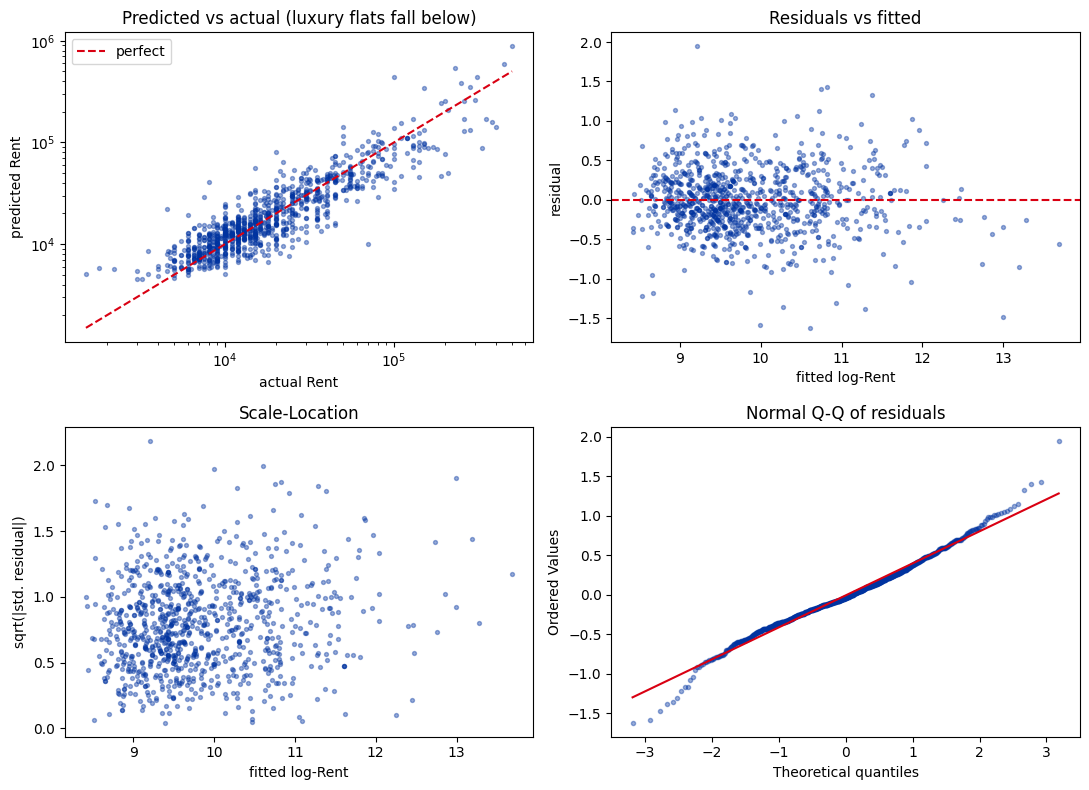

In [9]:
resid = ylog_te - p_log
std_resid = resid / resid.std()

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].scatter(yraw_te, p_raw, s=8, alpha=0.4, color=ARM_BLUE)
lim = [yraw_te.min(), yraw_te.max()]
ax[0, 0].plot(lim, lim, "--", color=ARM_RED, lw=1.5, label="perfect")
ax[0, 0].set(xscale="log", yscale="log", xlabel="actual Rent", ylabel="predicted Rent",
             title="Predicted vs actual (luxury flats fall below)"); ax[0, 0].legend()

ax[0, 1].scatter(p_log, resid, s=8, alpha=0.4, color=ARM_BLUE)
ax[0, 1].axhline(0, ls="--", color=ARM_RED, lw=1.5)
ax[0, 1].set(xlabel="fitted log-Rent", ylabel="residual", title="Residuals vs fitted")

ax[1, 0].scatter(p_log, np.sqrt(np.abs(std_resid)), s=8, alpha=0.4, color=ARM_BLUE)
ax[1, 0].set(xlabel="fitted log-Rent", ylabel="sqrt(|std. residual|)", title="Scale-Location")

stats.probplot(resid, dist="norm", plot=ax[1, 1])
ax[1, 1].get_lines()[0].set(marker="o", markersize=3, alpha=0.4, color=ARM_BLUE)
ax[1, 1].get_lines()[1].set(color=ARM_RED, lw=1.5)
ax[1, 1].set_title("Normal Q-Q of residuals")
plt.tight_layout(); plt.show()

### Segment diagnostic: error by city

A single number hides *where* the error lives. Median absolute error per city shows
which markets the model handles well vs poorly - more actionable than one global MAE.

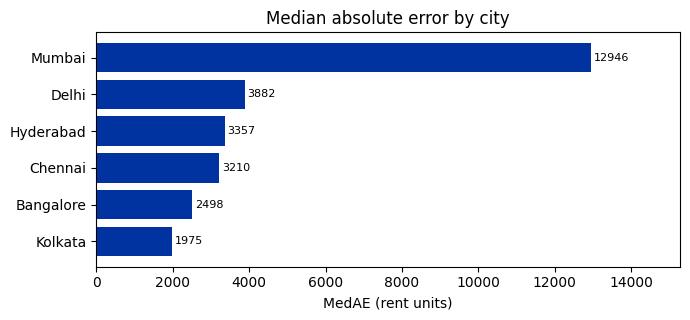

In [10]:
seg = (pd.DataFrame({"City": X_te["City"].values, "abs_err": np.abs(yraw_te - p_raw)})
       .groupby("City")["abs_err"].median().sort_values())
fig, ax = plt.subplots(figsize=(7, 3.3))
bars = ax.barh(seg.index, seg.values, color=ARM_BLUE)
ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
ax.set(title="Median absolute error by city", xlabel="MedAE (rent units)")
ax.margins(x=0.18)
plt.tight_layout(); plt.show()

### Validation & learning curves (L04)

**Validation curve** (CV R² vs alpha) is the U-curve from the lectures - here nearly
flat, so the penalty strength barely matters. **Learning curve** (score vs training
size): the train and CV curves meet at a low gap and plateau, so we are **bias-limited**
- more data would not help; a richer model class would.

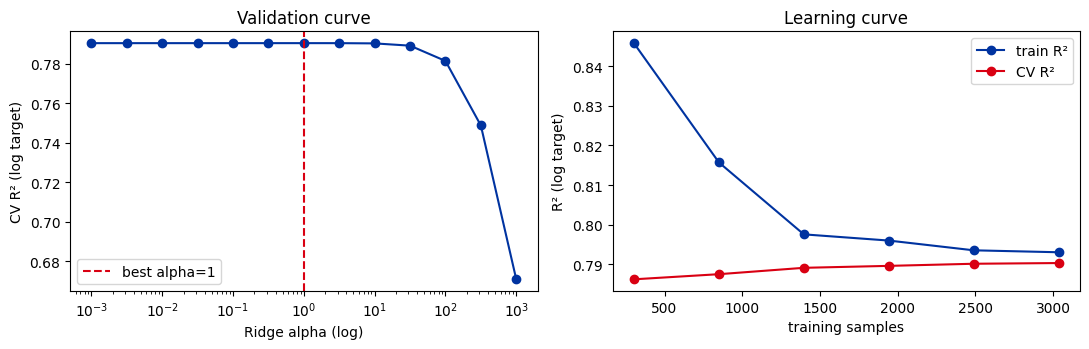

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
# validation curve - reuse the GridSearchCV results (no refit)
ax[0].plot(grid["ridge__alpha"], gs.cv_results_["mean_test_score"], "o-", color=ARM_BLUE)
ax[0].axvline(best, ls="--", color=ARM_RED, lw=1.5, label=f"best alpha={best:g}")
ax[0].set(xscale="log", xlabel="Ridge alpha (log)", ylabel="CV R² (log target)",
          title="Validation curve"); ax[0].legend()

# learning curve
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Found unknown categories")
    sizes, tr_sc, va_sc = learning_curve(
        gs.best_estimator_, X_tr, ylog_tr, train_sizes=np.linspace(0.1, 1.0, 6),
        cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
ax[1].plot(sizes, tr_sc.mean(1), "o-", color=ARM_BLUE, label="train R²")
ax[1].plot(sizes, va_sc.mean(1), "o-", color=ARM_RED, label="CV R²")
ax[1].set(xlabel="training samples", ylabel="R² (log target)", title="Learning curve"); ax[1].legend()
plt.tight_layout(); plt.show()

In [12]:
print("=" * 54)
print(" MODEL CARD - Rent predictor (honest)")
print("=" * 54)
print(f" Data        : House_Rent_Dataset.csv (n={len(df)}), target log1p(Rent)")
print(f" Model       : Ridge(alpha={best:g}), scaled numerics + OHE(drop=first), seed {SEED}")
print(f" Selection   : 5-fold CV on train; test evaluated ONCE")
print(f" Baseline    : DummyRegressor R2(log) = {dummy_cv:.3f}")
print(f" Test scores : log-R2 = {logR2:.3f}   MAE = {mae:,.0f}   MedAE = {medae:,.0f}   RMSE = {rmse:,.0f}")
print(f" Headline    : typical error (MedAE) ~ {medae:,.0f} rent units")
print(" Failure mode: under-predicts luxury flats (>=100k); RMSE tail-dominated")
print("=" * 54)

 MODEL CARD - Rent predictor (honest)
 Data        : House_Rent_Dataset.csv (n=4746), target log1p(Rent)
 Model       : Ridge(alpha=1), scaled numerics + OHE(drop=first), seed 509
 Selection   : 5-fold CV on train; test evaluated ONCE
 Baseline    : DummyRegressor R2(log) = -0.001
 Test scores : log-R2 = 0.799   MAE = 11,364   MedAE = 3,639   RMSE = 31,807
 Headline    : typical error (MedAE) ~ 3,639 rent units
 Failure mode: under-predicts luxury flats (>=100k); RMSE tail-dominated


## Going further (optional)

Two extras that apply more of the chapter's toolkit - **still only L04-L07 tools**
(no trees, that's Ch.3). Honest caveat: on this clean data neither beats the tuned
Ridge by much; the point is the *technique*, not the score.

### Lasso: L1 sparsity (L05)

Ridge shrinks every coefficient; **Lasso (L1)** drives some to *exactly zero* -
automatic feature selection. As `alpha` rises, more features drop out.

In [13]:
from sklearn.linear_model import Lasso
for a in [0.001, 0.01, 0.1, 0.3]:
    lasso = Pipeline([("pre", pre), ("lasso", Lasso(alpha=a, max_iter=50_000))]).fit(X_tr, ylog_tr)
    coef = lasso.named_steps["lasso"].coef_
    print(f"alpha={a:<6}: {int(np.sum(np.abs(coef) > 1e-6))}/{len(coef)} features kept")

alpha=0.001 : 11/12 features kept
alpha=0.01  : 10/12 features kept
alpha=0.1   : 4/12 features kept
alpha=0.3   : 1/12 features kept


### Bayesian optimization over more hyperparameters (L06)

Bayesian opt (Optuna's TPE) earns its keep when several hyperparameters interact -
not for a single Ridge `alpha`. So we tune a richer **in-chapter** model:
`PolynomialFeatures` (degree, interaction-only) feeding a **Ridge or Lasso** penalty -
Optuna also picks *which* penalty and its `alpha`, so four interacting hyperparameters,
all tools you've seen. *(On cheap linear fits random search would do just as well;
this shows the BO workflow.)*

In [14]:
import optuna
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge as RidgeReg, Lasso as LassoReg
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_pipe(model, degree, inter, alpha):
    reg = RidgeReg(alpha=alpha) if model == "ridge" else LassoReg(alpha=alpha, max_iter=50_000)
    pre2 = ColumnTransformer([
        ("num", Pipeline([("sc", StandardScaler()),
                          ("poly", PolynomialFeatures(degree, interaction_only=inter, include_bias=False))]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat)])
    return Pipeline([("pre", pre2), ("reg", reg)])

def objective(t):
    pipe = make_pipe(t.suggest_categorical("model", ["ridge", "lasso"]),
                     t.suggest_int("degree", 1, 3),
                     t.suggest_categorical("interaction_only", [True, False]),
                     t.suggest_float("alpha", 1e-3, 10, log=True))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return cross_val_score(pipe, X_tr, ylog_tr, cv=KFold(5, shuffle=True, random_state=SEED),
                               scoring="r2").mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=25)               # 25 cheap fits; single-threaded
print("best HPs:", study.best_params)
print("best CV R2(log) =", round(study.best_value, 3))

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


best HPs: {'model': 'ridge', 'degree': 3, 'interaction_only': False, 'alpha': 9.845470620601374}
best CV R2(log) = 0.795


In [15]:
bp = study.best_params
best_lin = make_pipe(bp["model"], bp["degree"], bp["interaction_only"], bp["alpha"]).fit(X_tr, ylog_tr)
pe = np.expm1(best_lin.predict(X_te))
print(f"Tuned {bp['model']}+poly (Optuna)  MAE = {mean_absolute_error(yraw_te, pe):,.0f}   "
      f"MedAE = {median_absolute_error(yraw_te, pe):,.0f}   RMSE = {mean_squared_error(yraw_te, pe)**0.5:,.0f}")
print(f"Ridge (Part 3)             MAE = {mae:,.0f}   MedAE = {medae:,.0f}   RMSE = {rmse:,.0f}")

Tuned ridge+poly (Optuna)  MAE = 10,328   MedAE = 3,562   RMSE = 27,329
Ridge (Part 3)             MAE = 11,364   MedAE = 3,639   RMSE = 31,807


A marginal edge over the tuned Ridge (mostly on the tail / RMSE), which confirms
the chapter's theme: on clean tabular data a well-tuned linear model is already
strong, and extra machinery buys little. The value here is the **workflow** -
adaptive search over several interacting hyperparameters - not the tiny bump.

## Conclusion

After fixing all twelve bugs, the honest sealed-test **log-R² is ~0.80** - below the
teammate's contaminated, in-sample number, far above the dummy baseline (~0). The
model is good for typical flats and under-predicts luxury ones.

The lesson: **most of the twelve bugs never moved the headline number.** The leak and
the log-units/in-sample reporting did; the rest printed a respectable R² while being
wrong. Audit the *code* against the rules, not the score.

**Bonus directions:** nested CV; target-encode `Area Locality` correctly inside CV
folds; permutation importance; Cook's-distance / leverage (OLS) influence check;
error by other segments (BHK, furnishing, size band).